In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)
# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 100, 'direction': 'x'},   
                20:   {'value': 100, 'direction': '-x'},   

}

In [5]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

In [6]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [7]:
# Nodes
for tag, (x, y, z) in mesh['nodes'].items():
    ops.node(tag, x, y)

In [8]:
# Boundary conditions
fixed_nodes = set()
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh['elements']:
        continue
    for connectivity in mesh['elements'][phys_id]['connectivity']:
        for tag in connectivity:
            fixed_nodes.add(tag)

for tag in fixed_nodes:
    rx = 1 if restrain_dictionary[18][0] == 'r' else 0
    ry = 1 if restrain_dictionary[18][1] == 'r' else 0
    ops.fix(tag, rx, ry)

In [9]:
# Material
solidMaterialTag = 1

nuYX = Steel.nu
nuZX = 0.20
nuZY = 0.20

Ex   = Steel.E
Ey   = 400
Ez   = 400

Gxy  = Ex / (2 * (1 + nuYX))
Gxz  = Ey / (2 * (1 + nuZX))
Gyz  = Ez / (2 * (1 + nuZY))

rho  = Steel.rho

ops.nDMaterial('ElasticOrthotropic', solidMaterialTag,
               Ex, Ey, Ez,
               nuYX, nuZX, nuZY,
               Gxy, Gxz, Gyz,
               rho)

In [10]:
# Elements
for elem_tag, connectivity in zip(mesh['elements'][17]['element_tags'],
                                  mesh['elements'][17]['connectivity']):
    
    ops.element('tri31', elem_tag, *connectivity,
                F1.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

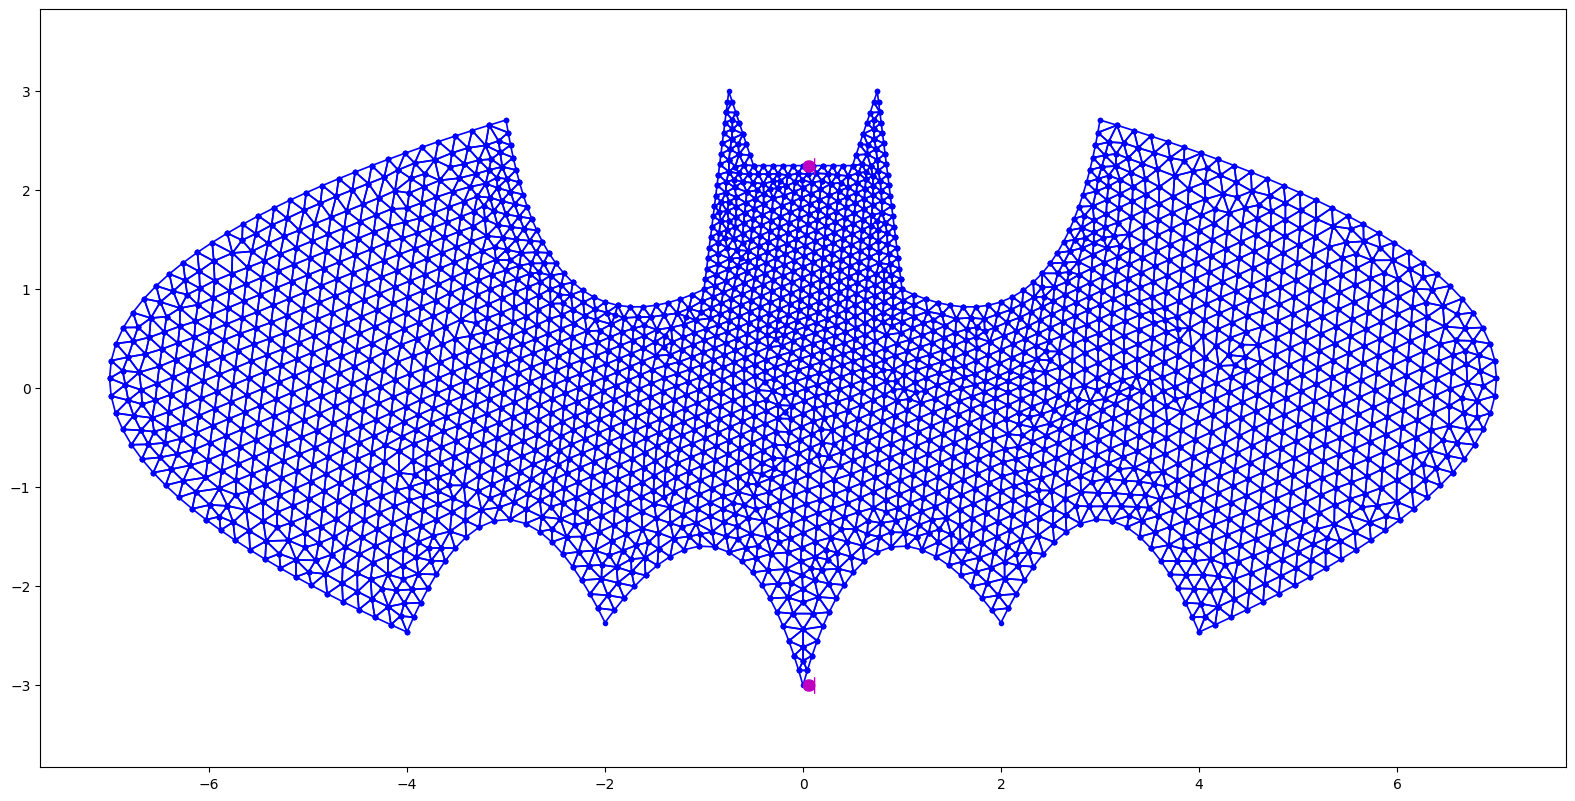

In [11]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [12]:
# Compute equivalent nodal loads
node_map, nodes = build_nodes(mesh, restrain_dictionary)
system_nDof     = len(nodes) * 2
F_load          = build_load_vector(mesh, node_map, load_dictionary, system_nDof)

# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))


In [13]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

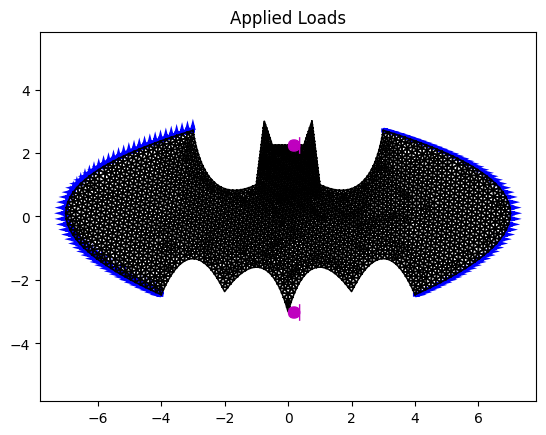

In [14]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

In [15]:
# Check first loaded node
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"node.name={node.name}  node.idx={node.idx}  fx={fx:.4f}  fy={fy:.4f}")
        print(f"F_load[{node.idx[0]}]={F_load[node.idx[0]]:.4f}")
        print(f"Total nodes: {len(nodes)}  system_nDof: {system_nDof}")
        break

node.name=11  node.idx=[20 21]  fx=-8.9578  fy=0.0000
F_load[20]=-8.9578
Total nodes: 2681  system_nDof: 5362


10

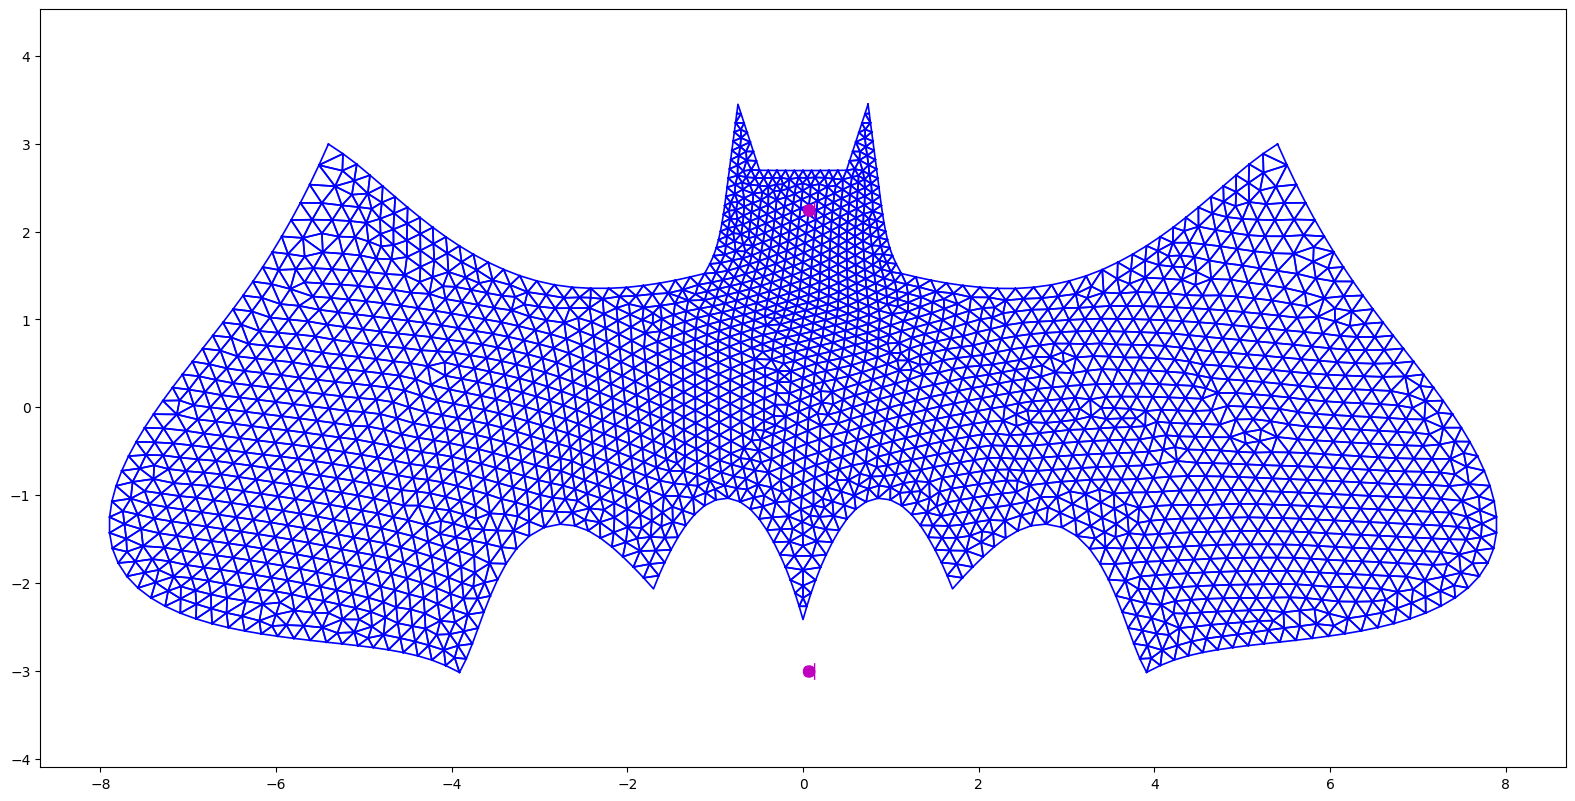

In [16]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'syy')

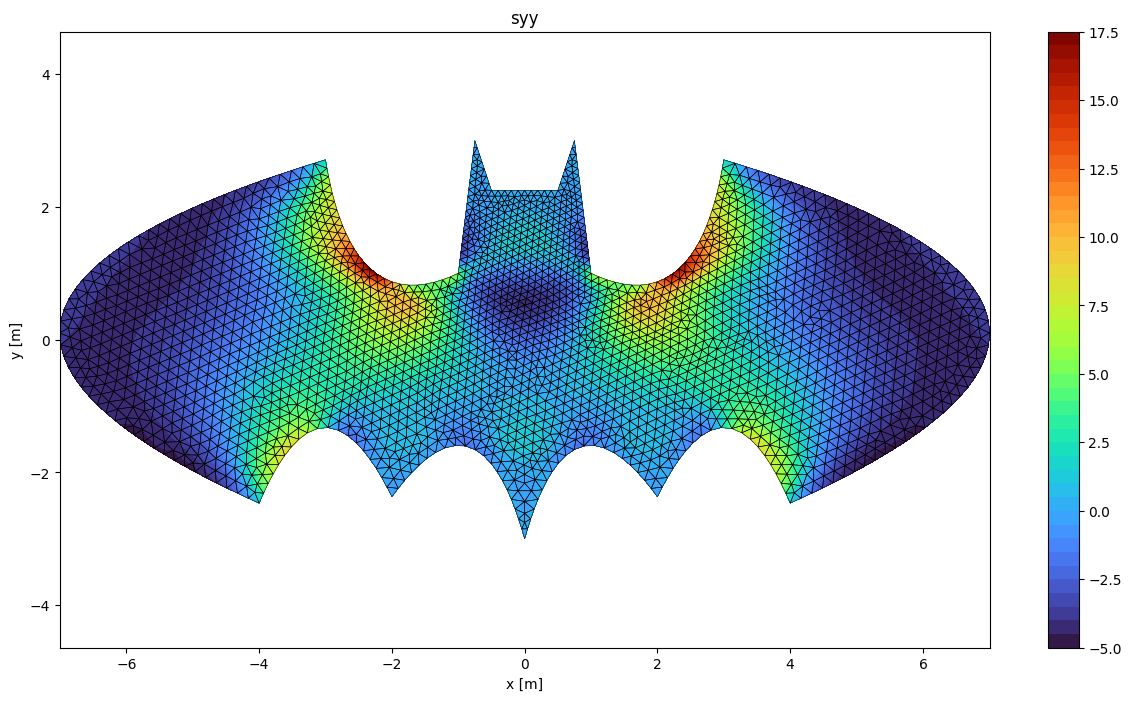

In [19]:
# jstr = 'sxx'
jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')